In [1]:
import math

import numpy as np

from modeling.constants import PLAYER_BASE_SPEED
from utility.Point2d import Point2d

with open("estimation_errors/localization_data.csv") as file:
    lines = file.readlines()
    pairs = []
    for line in lines:
        info = [v.strip() for v in line.split("|")]
        name = info[0]
        estimate = None
        real = None
        i = 1
        while i < len(info):
            prev_estimate = estimate
            prev_real = real
            estimate = info[i]
            real = info[i+1]
            assert estimate[0] == '(' and estimate[-1] == ')'
            assert real[0] == '(' and real[-1] == ')'
            estimate = Point2d(float(estimate.split(',')[0].strip()[1:]), float(estimate.split(',')[1].strip()[:-1]))
            real = Point2d(float(real.split(',')[0].strip()[1:]), float(real.split(',')[1].strip()[:-1]))
            if prev_estimate is not None:
                pairs.append([estimate - prev_estimate, real - prev_real])
            i += 2
    
    x1_errors = [pair[0].x1 - pair[1].x1 for pair in pairs]
    x2_errors = [pair[0].x2 - pair[1].x2 for pair in pairs]
    x1_estimate = [pair[0].x1 for pair in pairs]
    x2_estimate = [pair[0].x2 for pair in pairs]
    times = []
    for x1, x2 in zip(x1_estimate, x2_estimate):
        times.append(math.sqrt(x1**2+x2**2)/PLAYER_BASE_SPEED)
    x1_real = [pair[1].x1 for pair in pairs]
    x2_real = [pair[1].x2 for pair in pairs]

    normalized_x1_errors = []
    normalized_x2_errors = []
    for time, x1_error, x2_error, x1_real_value, x2_real_value in zip(times, x1_errors, x2_errors, x1_real, x2_real):
        normalized_x1_errors.append(x1_error/time)
        normalized_x2_errors.append(x2_error/time)




In [3]:
print(normalized_x1_errors)

[-0.41929868949423404, -0.48676972681420394, -0.6084839932842131, -0.06807325477250946, 0.05408820866267536, 0.19005340989727026, 0.11149323705362967, -0.0917499858877196, 0.059677010366464465, 0.03715996452200541, 0.12442891649079159, -0.005568814088690691, 1.0543170377704074, 0.07706422018348606, -0.044783504794691016, -7.58587788031601e-17, 1.0729605741817057, 0.0838877646504614, -0.0961520642473675, 0.05195313325600648, 0.8851594877318884, -0.11009174311926566, -0.22929322337793007, 0.0068397445745082925, 0.3539251626111288, 0.0, -0.0685760480135174, -0.028970716574562523, 0.40939246234890536, -0.026967973544401957, -0.01246399247789108, 1.2618316414806934e-15, 0.3335311849604659, -0.029072584661421166, -0.010383065950506927, -0.049046724798839744, 0.27831722121005636, -0.01898599963254743, -0.008674210011111376, 0.005760544042253834, -0.05286496236924803, 0.2984094066257871, -0.0058458707366447794, -0.0072297527630501394, 0.012972232251804766, -0.0802484765435588, 0.31110729926079

In [4]:
print(normalized_x2_errors)

[-0.4192986894942301, -0.48676972681420394, -0.6084839932842181, -0.7488058024976071, -0.612999698176968, -0.9185914811701374, 0.016631587847779235, -0.04401519593262248, 0.03260702628270711, 0.0006193327420336774, 0.03572711463596919, 0.0012375142419323456, -0.14180872437847336, -0.022018348623851765, -9.943935629295404e-16, -0.12982227582126413, 1.811220110132196e-15, 0.08388776465045741, -0.037392469429535176, -0.032470708284998824, 0.03688164532216834, 0.0660550458715592, 0.005592517643355085, -0.05471795659606087, 0.07382488054465207, 1.465036568577526e-15, 0.11221535129484483, -0.026742199914979496, 0.04647157680717217, -0.01037229751707762, 0.00207733207965085, 0.031199601233437953, 0.041967500094364577, 0.04568549018222989, -0.012459679140605067, -0.07579948378002428, 0.07731033922501516, 0.03359061473450835, -0.007228508342593669, -0.005760544042252299, -0.007831846276925453, 0.02873572063803941, 0.005845870736642703, -0.007229752763049626, -0.014413591390894471, 0.04697471797

In [12]:
np.cov([np.array(normalized_x1_errors)/1, np.array(normalized_x2_errors)/1])

array([[0.08172366, 0.01937269],
       [0.01937269, 0.05269392]])

In [13]:
import pandas as pd
all_data = pd.DataFrame(data={
    "normalized_x1_error": normalized_x1_errors, 
    "normalized_x2_error": normalized_x2_errors,
    "x1_estimate": x1_estimate,
    "x2_estimate": x2_estimate,
    "x1_real": x1_real,
    "x2_real": x2_real,
    "time" : times
    })

In [14]:
all_data.sort_values(by="time").to_csv("estimation_errors/normalized_errors.csv", index=False)

<AxesSubplot:>

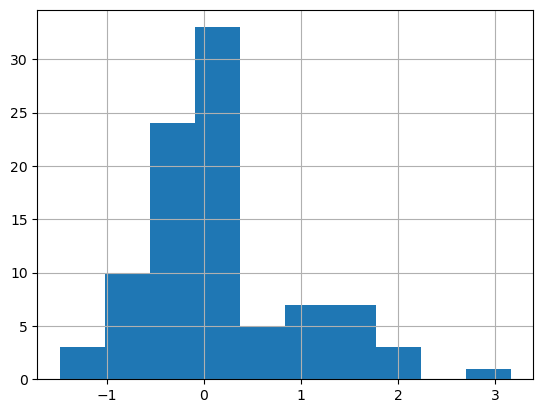

In [3]:
pd.Series(x1_errors).hist()

<AxesSubplot:>

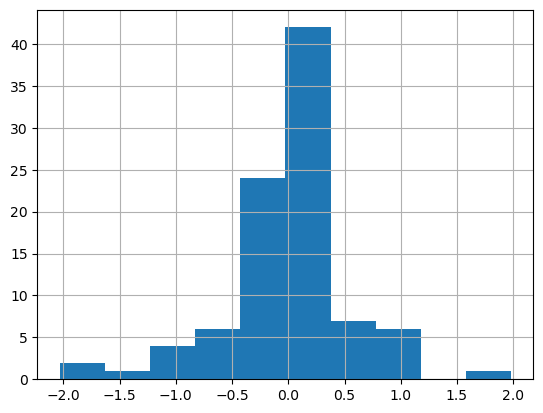

In [4]:
pd.Series(x2_errors).hist()

In [5]:
np.corrcoef(x1_errors, x1_estimate)

array([[1.        , 0.40896429],
       [0.40896429, 1.        ]])

In [7]:
np.corrcoef(x2_errors, x2_estimate)

array([[1.        , 0.30289112],
       [0.30289112, 1.        ]])

In [6]:
np.corrcoef(x1_errors, x1_real)

array([[1.        , 0.38878168],
       [0.38878168, 1.        ]])

In [8]:
np.corrcoef(x2_errors, x2_real)

array([[1.        , 0.27309503],
       [0.27309503, 1.        ]])

In [9]:
np.corrcoef(x1_estimate, x1_real)

array([[1.        , 0.99975779],
       [0.99975779, 1.        ]])

In [10]:
np.corrcoef(x2_estimate, x2_real)

array([[1.        , 0.99951594],
       [0.99951594, 1.        ]])